# SECTION 1: Environment Setup\nConfigure environment variables, and import required libraries including FAISS and Scikit-Learn.

In [9]:
import os
os.environ['TF_USE_LEGACY_KERAS'] = '1'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_recommenders as tfrs
import faiss
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

print(f"TensorFlow Version: {tf.__version__}")
print(f"FAISS Version: {faiss.__version__}")


TensorFlow Version: 2.18.0
FAISS Version: 1.7.4


# SECTION 2: Load Model\nDefine the paths to load the trained weights and datasets.

In [10]:
weights_path = '../model_weights/two_tower.weights.h5'
products_path = 'processed_products.csv'
interactions_path = 'processed_interactions.csv'

products_df = pd.read_csv(products_path)
train_interactions_df = pd.read_csv(interactions_path)

# Ensure ID columns are treated as strings
products_df['id'] = products_df['id'].astype(str)
train_interactions_df['user_id'] = train_interactions_df['user_id'].astype(str)
train_interactions_df['product_id'] = train_interactions_df['product_id'].astype(str)

unique_product_ids = np.unique(products_df['id'].values)
unique_user_ids = np.unique(train_interactions_df['user_id'].values)

print(f"Loaded {len(unique_product_ids)} unique products and {len(unique_user_ids)} unique users.")
print(f"Weights will be loaded from: {weights_path}")


Loaded 600 unique products and 1002 unique users.
Weights will be loaded from: ../model_weights/two_tower.weights.h5


# SECTION 3: Rebuild Product Tower\nRecreate the exact architecture used during training to successfully load the weights.

In [11]:
embedding_dimension = 64

# 1. Rebuild User Model
class UserModel(tf.keras.Model):
    def __init__(self, unique_user_ids):
        super().__init__()
        self.user_embedding = tf.keras.Sequential([
            tf.keras.layers.StringLookup(vocabulary=unique_user_ids, mask_token=None),
            tf.keras.layers.Embedding(len(unique_user_ids) + 1, embedding_dimension)
        ])
        
    def call(self, inputs):
        return self.user_embedding(inputs)

# 2. Rebuild Product Model (Exact match to training)
class AdvancedProductModel(tf.keras.Model):
    def __init__(self, unique_product_ids):
        super().__init__()
        self.product_id_embedding = tf.keras.Sequential([
            tf.keras.layers.StringLookup(vocabulary=unique_product_ids, mask_token=None),
            tf.keras.layers.Embedding(len(unique_product_ids) + 1, embedding_dimension)
        ])
        
    def call(self, inputs):
        return self.product_id_embedding(inputs)

# 3. Rebuild Two Tower Assembly
class TwoTowerECommerceModel(tfrs.Model):
    def __init__(self, user_model, product_model):
        super().__init__()
        self.user_model = user_model
        self.product_model = product_model
        # We dummy out the task here since we only need to extract embeddings
        self.task = tfrs.tasks.Retrieval()
        
    def call(self, features):
        return (self.user_model(features['user_id']), 
                self.product_model(features['product_id']))
    def compute_loss(self, features, training=False):
        user_embeddings = self.user_model(features["user_id"])
        product_embeddings = self.product_model(features["product_id"])
        return self.task(user_embeddings, product_embeddings)

# Instantiate
user_model = UserModel(unique_user_ids)
product_model = AdvancedProductModel(unique_product_ids)
model = TwoTowerECommerceModel(user_model, product_model)

# Build the model eagerly by passing dummy data
dummy_user = tf.constant(["dummy_user"])
dummy_product = tf.constant(["dummy_product"])
model({"user_id": dummy_user, "product_id": dummy_product})

# Load the weights
model.load_weights(weights_path)
print("Model architecture rebuilt and weights successfully loaded!")


Model architecture rebuilt and weights successfully loaded!


# SECTION 4: Generate Product Embeddings\nPass all 600 products through the Product Tower to generate 64-dimensional embeddings.

In [12]:
# Get all product IDs as a tensor
all_product_ids = tf.constant(products_df['id'].values)

# Generate embeddings (this runs them through the Embedding layer)
product_embeddings_tensor = model.product_model(all_product_ids)

# Convert to numpy array for FAISS
product_embeddings = product_embeddings_tensor.numpy()

print(f"Generated embeddings for {len(all_product_ids)} products.")


Generated embeddings for 600 products.


# SECTION 5: Save Embeddings\nSave `product_embeddings.npy` and `product_ids.npy` for later use.

In [13]:
import os

export_dir = '../embeddings'
os.makedirs(export_dir, exist_ok=True)

emb_path = os.path.join(export_dir, 'product_embeddings.npy')
id_path = os.path.join(export_dir, 'product_ids.npy')

np.save(emb_path, product_embeddings)
np.save(id_path, products_df['id'].values)

print(f"Saved embeddings to: {emb_path}")
print(f"Saved product IDs to: {id_path}")


Saved embeddings to: ../embeddings\product_embeddings.npy
Saved product IDs to: ../embeddings\product_ids.npy


# SECTION 6: Embedding Validation\nCheck the shape, data types, and check for missing values to ensure integrity.

In [14]:
print("=== EMBEDDING VALIDATION ===")
print(f"Shape: {product_embeddings.shape}")
print(f"Data Type: {product_embeddings.dtype}")
print(f"Missing Values (NaNs): {np.isnan(product_embeddings).sum()}")

# Assertions
assert product_embeddings.shape[0] == len(products_df), "Mismatch in row counts!"
assert product_embeddings.shape[1] == 64, "Embedding dimension is not 64!"
assert np.isnan(product_embeddings).sum() == 0, "Embeddings contain NaN values!"

print("Validation passed. Embeddings are clean and structurally sound.")


=== EMBEDDING VALIDATION ===
Shape: (600, 64)
Data Type: float32
Missing Values (NaNs): 0
Validation passed. Embeddings are clean and structurally sound.


# SECTION 7: Create FAISS Index\nCreate an Inner Product FAISS Index (`IndexFlatIP`) for lightning-fast retrieval.

In [15]:
# FAISS requires float32 data
faiss_embeddings = product_embeddings.astype('float32')

# Create the index (Inner Product / Dot Product aligns with TFRS factorized retrieval)
dimension = faiss_embeddings.shape[1]
faiss_index = faiss.IndexFlatIP(dimension)

# Add embeddings to the index
faiss_index.add(faiss_embeddings)

index_path = os.path.join(export_dir, 'faiss_index.bin')
faiss.write_index(faiss_index, index_path)

print(f"FAISS Index created and saved to: {index_path}")
print(f"Total vectors in FAISS index: {faiss_index.ntotal}")


FAISS Index created and saved to: ../embeddings\faiss_index.bin
Total vectors in FAISS index: 600


# SECTION 8: Similar Product Search\nTest the FAISS index by querying a product to find its top 10 most similar counterparts.

In [16]:
# Pick a random product
query_idx = 0  # Assuming the first product
query_product_id = products_df.iloc[query_idx]['id']
query_product_name = products_df.iloc[query_idx]['name']

# Get its embedding and reshape for FAISS (batch_size, dimension)
query_vector = faiss_embeddings[query_idx].reshape(1, -1)

# Search FAISS
k = 10
distances, indices = faiss_index.search(query_vector, k+1) # k+1 because it will return itself

print(f"Top 10 Similar Products to '{query_product_name}' (ID: {query_product_id}):")
# Skip the first one because it's the product itself (distance ~ max)
for i in range(1, k+1):
    idx = indices[0][i]
    dist = distances[0][i]
    similar_id = products_df.iloc[idx]['id']
    similar_name = products_df.iloc[idx]['name']
    print(f" {i}. {similar_name} (ID: {similar_id}) | Score: {dist:.4f}")


Top 10 Similar Products to 'Huawei Slim Laptop Intel i7' (ID: 2):
 1. Xiaomi Ultra HD TV Premium (ID: 441) | Score: 3.8587
 2. LG Smart TV Premium (ID: 428) | Score: 2.7761
 3. Samsung OLED TV Premium (ID: 444) | Score: 2.6638
 4. Samsung Ultra HD TV Android (ID: 470) | Score: 2.6454
 5. Acer Gaming Laptop Apple M2 (ID: 11) | Score: 2.6304
 6. LG OLED TV Premium (ID: 447) | Score: 2.6018
 7. HP Ultra Laptop Intel i5 (ID: 50) | Score: 2.5861
 8. MSI Gaming Laptop Intel i5 (ID: 41) | Score: 2.5603
 9. HP Business Laptop Intel i5 (ID: 55) | Score: 2.5115
 10. Apple Gaming Laptop Apple M2 (ID: 40) | Score: 2.4977


# SECTION 9: Utility Functions\nCreate reusable helper functions for retrieving embeddings and making recommendations.

In [17]:
def get_product_embedding(product_id_str):
    idx = products_df.index[products_df['id'] == str(product_id_str)].tolist()
    if not idx:
        return None
    return faiss_embeddings[idx[0]].reshape(1, -1)

def find_similar_products(product_id_str, k=10):
    vec = get_product_embedding(product_id_str)
    if vec is None:
        return []
    
    distances, indices = faiss_index.search(vec, k+1)
    
    similar_products = []
    for i in range(1, k+1):
        idx = indices[0][i]
        similar_products.append({
            'id': products_df.iloc[idx]['id'],
            'name': products_df.iloc[idx]['name'],
            'score': distances[0][i]
        })
    return similar_products

def recommend_products(user_id_str, k=10):
    # Pass user_id through the User Tower to get their 64D query vector
    user_tensor = tf.constant([str(user_id_str)])
    user_vector = model.user_model(user_tensor).numpy().astype('float32')
    
    # Search FAISS
    distances, indices = faiss_index.search(user_vector, k)
    
    recommendations = []
    for i in range(k):
        idx = indices[0][i]
        recommendations.append({
            'id': products_df.iloc[idx]['id'],
            'name': products_df.iloc[idx]['name'],
            'score': distances[0][i]
        })
    return recommendations

print("Utility functions initialized.")


Utility functions initialized.


# SECTION 10: Embedding Visualization\nUse PCA and t-SNE to visualize product clusters in 2D space.

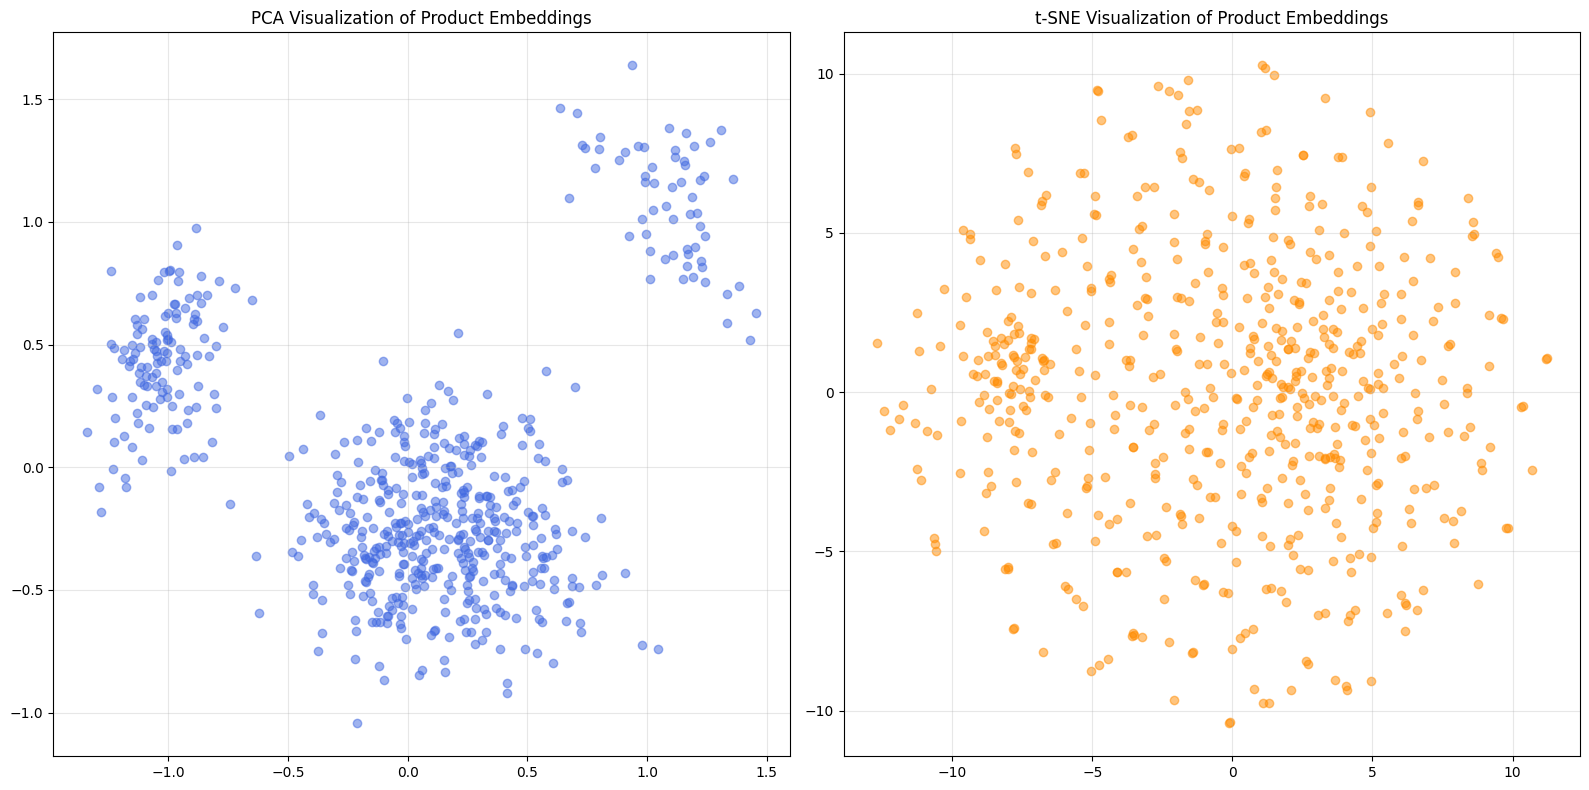

In [18]:
# PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(product_embeddings)

# t-SNE (usually gives better localized clusters)
tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42)
tsne_result = tsne.fit_transform(product_embeddings)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Plot PCA
ax1.scatter(pca_result[:, 0], pca_result[:, 1], alpha=0.5, color='royalblue')
ax1.set_title('PCA Visualization of Product Embeddings')
ax1.grid(True, alpha=0.3)

# Plot t-SNE
ax2.scatter(tsne_result[:, 0], tsne_result[:, 1], alpha=0.5, color='darkorange')
ax2.set_title('t-SNE Visualization of Product Embeddings')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# SECTION 11: Recommendation Testing\nTest the `recommend_products` function for a sample user.

In [19]:
sample_user = str(np.random.choice(unique_user_ids))

print(f"Generating recommendations for User ID: {sample_user}\n")
recs = recommend_products(sample_user, k=10)

for i, rec in enumerate(recs, 1):
    print(f"{i}. {rec['name']} (Score: {rec['score']:.4f})")


Generating recommendations for User ID: 322

1. Logitech Gaming Mouse Rechargeable (Score: 3.8367)
2. Samsung Smart Watch Premium (Score: 3.7323)
3. Vivo Max Mobile 256GB (Score: 3.5917)
4. Redragon RGB Keyboard Premium (Score: 3.3015)
5. OnePlus Note Mobile 256GB (Score: 3.2910)
6. Razer RGB Mouse Fast (Score: 3.2091)
7. Sony Professional Camera Lens Kit (Score: 2.9902)
8. Razer Wireless Mouse Fast (Score: 2.9075)
9. Apple Sports Watch AMOLED (Score: 2.7664)
10. Logitech Wireless Keyboard Premium (Score: 2.7330)


# SECTION 12: Django Integration\nCode snippets that you can copy/paste into your Django application.

In [20]:
django_snippets = """
# ==========================================
# 1. Loading Embeddings and FAISS (apps.py / Singleton)
# ==========================================
import faiss
import numpy as np

# Load FAISS Index globally once on startup
FAISS_INDEX_PATH = 'ml_data/embeddings/faiss_index.bin'
PRODUCT_IDS_PATH = 'ml_data/embeddings/product_ids.npy'

class RecommendationEngine:
    _index = None
    _product_ids = None
    
    @classmethod
    def load_index(cls):
        if cls._index is None:
            cls._index = faiss.read_index(FAISS_INDEX_PATH)
            cls._product_ids = np.load(PRODUCT_IDS_PATH, allow_pickle=True)
            
    @classmethod
    def get_similar_products(cls, product_vector_float32, k=10):
        cls.load_index()
        distances, indices = cls._index.search(product_vector_float32, k)
        
        # Map back to real product IDs
        recommended_ids = [cls._product_ids[idx] for idx in indices[0]]
        return recommended_ids

# ==========================================
# 2. Caching Recommendations (Redis / Django Cache)
# ==========================================
from django.core.cache import cache

def get_cached_recommendations(user_id):
    cache_key = f"recs_user_{user_id}"
    recs = cache.get(cache_key)
    
    if not recs:
        # User tower inference here (returns float32 numpy array)
        # user_vector = user_tower_model(user_id).numpy().astype('float32')
        
        # recs = RecommendationEngine.get_similar_products(user_vector, k=10)
        
        # Cache for 1 hour
        # cache.set(cache_key, recs, 3600)
        pass
    return recs
"""

print(django_snippets)



# ==========================================
# 1. Loading Embeddings and FAISS (apps.py / Singleton)
# ==========================================
import faiss
import numpy as np

# Load FAISS Index globally once on startup
FAISS_INDEX_PATH = 'ml_data/embeddings/faiss_index.bin'
PRODUCT_IDS_PATH = 'ml_data/embeddings/product_ids.npy'

class RecommendationEngine:
    _index = None
    _product_ids = None
    
    @classmethod
    def load_index(cls):
        if cls._index is None:
            cls._index = faiss.read_index(FAISS_INDEX_PATH)
            cls._product_ids = np.load(PRODUCT_IDS_PATH, allow_pickle=True)
            
    @classmethod
    def get_similar_products(cls, product_vector_float32, k=10):
        cls.load_index()
        distances, indices = cls._index.search(product_vector_float32, k)
        
        # Map back to real product IDs
        recommended_ids = [cls._product_ids[idx] for idx in indices[0]]
        return recommended_ids

# ===============================

In [21]:
import os

print("Current:", os.getcwd())
print("Export path:", os.path.abspath("../embeddings"))
print("Files:", os.listdir("../embeddings"))

Current: c:\Users\rudra\Downloads\E-Commerce-Website\myproject\ml_data\notebooks
Export path: c:\Users\rudra\Downloads\E-Commerce-Website\myproject\ml_data\embeddings
Files: ['faiss_index.bin', 'product_embeddings.npy', 'product_ids.npy', 'user_embeddings.npy', 'user_ids.npy']
